In [1]:
import os
os.chdir('/Users/krittitee/Compro2_DataExploration/date time')
os.getcwd()

'/Users/krittitee/Compro2_DataExploration/date time'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#Data soucre: https://www.kaggle.com/datasets/sanjanchaudhari/beach-weather-stations?resource=download

orig_df = pd.read_csv('beach_weather_stations_partial.csv')
orig_df.head()

,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation
0,63rd Street Weather Station,09/27/2018 10:00:00 AM,16.40,61,0.0,0.0,260.3,231,2.5,4.7,996.3,484
1,63rd Street Weather Station,09/27/2018 11:00:00 AM,17.10,51,0.0,0.0,260.3,244,3.6,5.7,995.4,468
2,63rd Street Weather Station,09/27/2018 01:00:00 PM,18.20,51,0.0,0.0,260.3,248,3.1,5.3,994.8,377
3,Foster Weather Station,09/27/2018 01:00:00 PM,17.89,39,NaN,0.0,NaN,249,1.4,2.3,993.6,0
4,63rd Street Weather Station,09/27/2018 03:00:00 PM,19.50,47,0.0,0.0,260.3,249,3.1,5.7,992.9,461


In [4]:
df = orig_df.copy()
df.dtypes

Station Name              object
Measurement Timestamp     object
Air Temperature          float64
Humidity                   int64
Rain Intensity           float64
Interval Rain            float64
Total Rain               float64
Wind Direction             int64
Wind Speed               float64
Maximum Wind Speed       float64
Barometric Pressure      float64
Solar Radiation            int64
dtype: object

In [5]:
df.columns

Index(['Station Name', 'Measurement Timestamp', 'Air Temperature', 'Humidity',
       'Rain Intensity', 'Interval Rain', 'Total Rain', 'Wind Direction',
       'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure',
       'Solar Radiation'],
      dtype='object')

##### String Time Format Code List
https://strftime.org/

In [6]:
# Set column 'Measurement Timestamp' to be index of dataframe and convert the index to datetime data type
# Set original column 'Measurement Timestamp' to be datetime data type

df.index = pd.to_datetime(df['Measurement Timestamp'], format='%m/%d/%Y %I:%M:%S %p')
df['Measurement Timestamp'] = pd.to_datetime(df['Measurement Timestamp'], format='%m/%d/%Y %I:%M:%S %p')
df.head()

,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation
Measurement Timestamp,,,,,,,,,,,,
2018-09-27 10:00:00,63rd Street Weather Station,2018-09-27 10:00:00,16.40,61,0.0,0.0,260.3,231,2.5,4.7,996.3,484
2018-09-27 11:00:00,63rd Street Weather Station,2018-09-27 11:00:00,17.10,51,0.0,0.0,260.3,244,3.6,5.7,995.4,468
2018-09-27 13:00:00,63rd Street Weather Station,2018-09-27 13:00:00,18.20,51,0.0,0.0,260.3,248,3.1,5.3,994.8,377
2018-09-27 13:00:00,Foster Weather Station,2018-09-27 13:00:00,17.89,39,NaN,0.0,NaN,249,1.4,2.3,993.6,0
2018-09-27 15:00:00,63rd Street Weather Station,2018-09-27 15:00:00,19.50,47,0.0,0.0,260.3,249,3.1,5.7,992.9,461


In [7]:
# Check data types of Measurement Timestamp columns again

df.dtypes

Station Name                     object
Measurement Timestamp    datetime64[ns]
Air Temperature                 float64
Humidity                          int64
Rain Intensity                  float64
Interval Rain                   float64
Total Rain                      float64
Wind Direction                    int64
Wind Speed                      float64
Maximum Wind Speed              float64
Barometric Pressure             float64
Solar Radiation                   int64
dtype: object

## Sampling Frequency

##### Sampling frequency code for different rate  

Source: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases <br>

In [8]:
# The data are given in hourly sampling rate.  
# The data can be sampled in other different frequencies.

# One sample = one data over time period
# Sampling frequency code is used to specify sampling rate
# For example: 
# 'YE' specifies one sample per year
# 'QE' specifies one sample per quarter (3 months)
# 'ME' specifies one sample per month
# (See more sampling frequency code examples in link above.)
    
annual_df = df['Total Rain'].resample('YE').mean() 
quarter_df  = df['Total Rain'].resample('QE').mean()  
monthly_df  = df['Total Rain'].resample('ME').mean()  

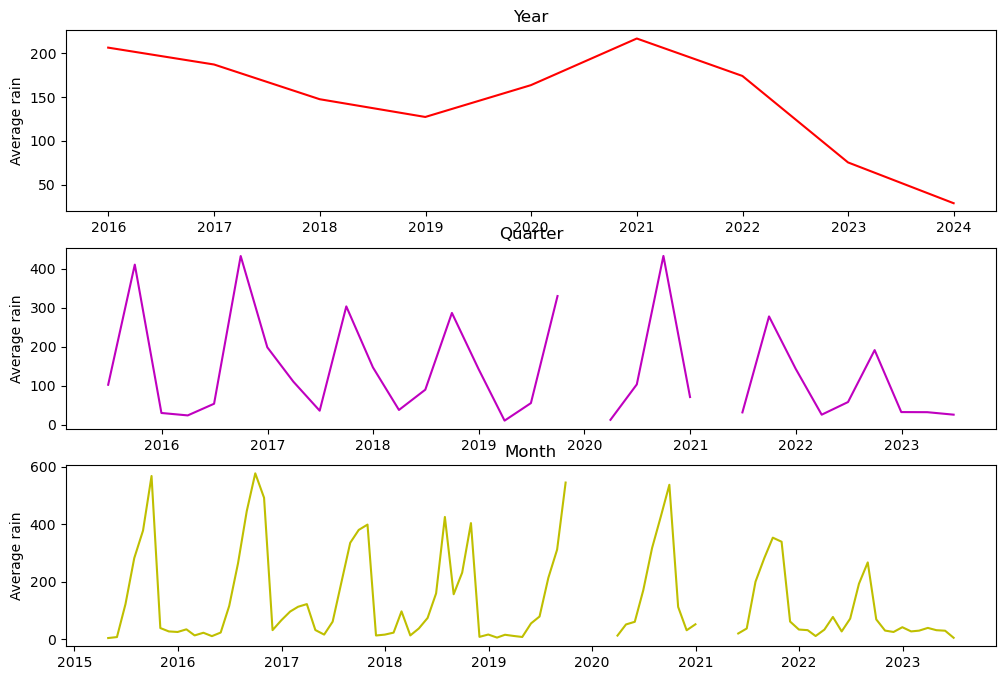

In [9]:
# plot 3 graphs for different sampling frequencies
# Notice the differences among results

fig, ax = plt.subplots(3,1, figsize = (12,8))
ax[0].plot(annual_df.index, annual_df, 'r-')
ax[0].set_ylabel('Average rain')
ax[0].set_title('Year')
ax[1].plot(quarter_df.index, quarter_df, 'm-')
ax[1].set_ylabel('Average rain')
ax[1].set_title('Quarter')
ax[2].plot(monthly_df.index, monthly_df, 'y-')
ax[2].set_ylabel('Average rain')
ax[2].set_title('Month')
plt.show()

## Datetime Functionality

#### Help link:

https://docs.python.org/3/library/datetime.html

In [10]:
import datetime
begin_time = datetime.datetime(2016, 1, 1)
end_time = datetime.datetime(2016, 12, 31)

In [11]:
# Find datetime duration
end_time - begin_time

datetime.timedelta(days=365)

In [12]:
# Find unique stations that collect weather measurements

df['Station Name'].unique()

array(['63rd Street Weather Station', 'Foster Weather Station',
       'Oak Street Weather Station'], dtype=object)

In [13]:
# How to use datetime for comparison

# Filter data only in the scope of interest
filtered_df = df[(df['Station Name'] == '63rd Street Weather Station') & 
                 (df['Measurement Timestamp'] >= begin_time) & 
                 (df['Measurement Timestamp'] <= end_time)]
filtered_df.head()

,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation
Measurement Timestamp,,,,,,,,,,,,
2016-01-01 01:00:00,63rd Street Weather Station,2016-01-01 01:00:00,-3.4,72,0.0,0.0,6.7,273,6.4,9.4,999.9,5
2016-01-01 02:00:00,63rd Street Weather Station,2016-01-01 02:00:00,-4.2,71,0.0,0.0,6.7,261,6.2,9.8,999.6,5
2016-01-01 03:00:00,63rd Street Weather Station,2016-01-01 03:00:00,-5.1,70,0.0,0.0,6.7,277,7.1,10.0,999.1,5
2016-01-01 04:00:00,63rd Street Weather Station,2016-01-01 04:00:00,-5.7,72,0.0,0.0,6.7,276,7.7,10.3,998.9,5
2016-01-01 05:00:00,63rd Street Weather Station,2016-01-01 05:00:00,-6.3,75,0.0,0.0,6.7,280,5.2,8.8,998.8,5


## Statistics over Time

In [14]:
# Besides sampling at different sampling rate, 
# different statistics can be computed.
# For example: mean, sum, count, etc.

# One sample = one statistics over time period
ave_df = filtered_df['Total Rain'].resample('W').mean()  
sum_df = filtered_df['Total Rain'].resample('W').sum()  
count_df = filtered_df['Total Rain'].resample('W').count() 

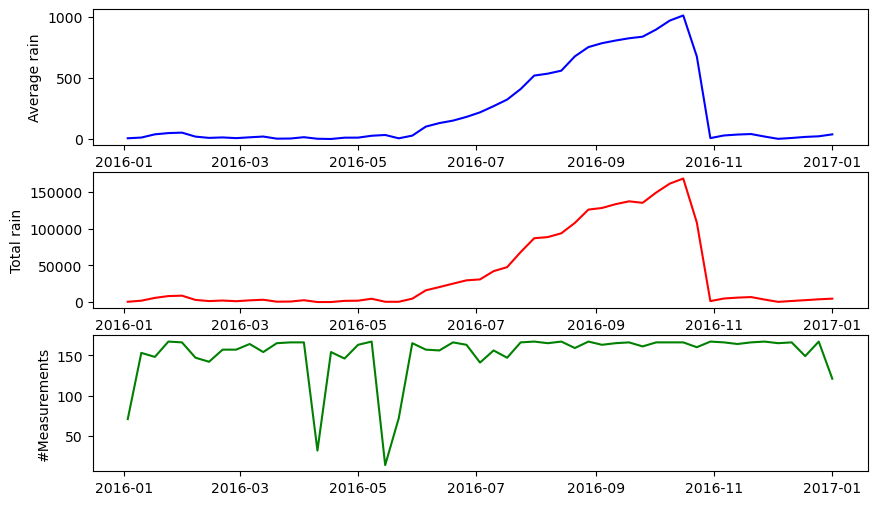

In [15]:
# plot 3 graphs for 3 different statistics
# Notice the differences among results

fig, ax = plt.subplots(3,1, figsize = (10,6))
ax[0].plot(ave_df.index, ave_df, 'b-')
ax[0].set_ylabel('Average rain')
ax[1].plot(sum_df.index, sum_df, 'r-')
ax[1].set_ylabel('Total rain')
ax[2].plot(count_df.index, count_df, 'g-')
ax[2].set_ylabel('#Measurements')
plt.show()

## Create New Column by Applying Function to Specific Column

In [16]:
def get_month(obj):
  return obj.month

# Create new column called 'month' by extracting month from 'Measurement Timestamp' column
df['month'] = df['Measurement Timestamp'].apply(get_month)
df.head()

,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation,month
Measurement Timestamp,,,,,,,,,,,,,
2018-09-27 10:00:00,63rd Street Weather Station,2018-09-27 10:00:00,16.40,61,0.0,0.0,260.3,231,2.5,4.7,996.3,484,9
2018-09-27 11:00:00,63rd Street Weather Station,2018-09-27 11:00:00,17.10,51,0.0,0.0,260.3,244,3.6,5.7,995.4,468,9
2018-09-27 13:00:00,63rd Street Weather Station,2018-09-27 13:00:00,18.20,51,0.0,0.0,260.3,248,3.1,5.3,994.8,377,9
2018-09-27 13:00:00,Foster Weather Station,2018-09-27 13:00:00,17.89,39,NaN,0.0,NaN,249,1.4,2.3,993.6,0,9
2018-09-27 15:00:00,63rd Street Weather Station,2018-09-27 15:00:00,19.50,47,0.0,0.0,260.3,249,3.1,5.7,992.9,461,9


In [17]:
def classify_wind_strength(obj):
    if obj > 0 and obj < 1:
        return 'Calm'
    elif obj >= 1 and obj < 7:
        return 'Light'
    elif obj >= 8 and obj < 31:
        return 'Breeze'
    elif obj >= 32 and obj < 54:
        return 'Gale'
    elif obj >= 55:
        return 'Storm'

# Create new column called 'Wind Strength' by classify values of Wind Speed column 
df['Wind Strength'] = df['Wind Speed'].apply(classify_wind_strength)
df.head()

,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation,month,Wind Strength
Measurement Timestamp,,,,,,,,,,,,,,
2018-09-27 10:00:00,63rd Street Weather Station,2018-09-27 10:00:00,16.40,61,0.0,0.0,260.3,231,2.5,4.7,996.3,484,9,Light
2018-09-27 11:00:00,63rd Street Weather Station,2018-09-27 11:00:00,17.10,51,0.0,0.0,260.3,244,3.6,5.7,995.4,468,9,Light
2018-09-27 13:00:00,63rd Street Weather Station,2018-09-27 13:00:00,18.20,51,0.0,0.0,260.3,248,3.1,5.3,994.8,377,9,Light
2018-09-27 13:00:00,Foster Weather Station,2018-09-27 13:00:00,17.89,39,NaN,0.0,NaN,249,1.4,2.3,993.6,0,9,Light
2018-09-27 15:00:00,63rd Street Weather Station,2018-09-27 15:00:00,19.50,47,0.0,0.0,260.3,249,3.1,5.7,992.9,461,9,Light


In [18]:
def check_storm(obj, genre_val):
    if obj == genre_val:
        return 1
    return 0

# Create new column called 'Storm'. If 'Wind Strength' is storm, Storm value is 1.
df['Storm'] = df['Wind Strength'].apply(check_storm ,args=('Storm',))
df.head()

,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation,month,Wind Strength,Storm
Measurement Timestamp,,,,,,,,,,,,,,,
2018-09-27 10:00:00,63rd Street Weather Station,2018-09-27 10:00:00,16.40,61,0.0,0.0,260.3,231,2.5,4.7,996.3,484,9,Light,0
2018-09-27 11:00:00,63rd Street Weather Station,2018-09-27 11:00:00,17.10,51,0.0,0.0,260.3,244,3.6,5.7,995.4,468,9,Light,0
2018-09-27 13:00:00,63rd Street Weather Station,2018-09-27 13:00:00,18.20,51,0.0,0.0,260.3,248,3.1,5.3,994.8,377,9,Light,0
2018-09-27 13:00:00,Foster Weather Station,2018-09-27 13:00:00,17.89,39,NaN,0.0,NaN,249,1.4,2.3,993.6,0,9,Light,0
2018-09-27 15:00:00,63rd Street Weather Station,2018-09-27 15:00:00,19.50,47,0.0,0.0,260.3,249,3.1,5.7,992.9,461,9,Light,0


In [19]:
# Find out how many measurements that have Storm value = 1
print(len(df[df['Storm'] == 1]))
df[df['Storm'] == 1]

4


,Station Name,Measurement Timestamp,Air Temperature,Humidity,Rain Intensity,Interval Rain,Total Rain,Wind Direction,Wind Speed,Maximum Wind Speed,Barometric Pressure,Solar Radiation,month,Wind Strength,Storm
Measurement Timestamp,,,,,,,,,,,,,,,
2016-02-24 12:00:00,63rd Street Weather Station,2016-02-24 12:00:00,0.4,98,0.0,1.8,16.9,280,999.9,999.9,978.2,70,2,Storm,1
2016-02-24 13:00:00,63rd Street Weather Station,2016-02-24 13:00:00,0.5,98,1.8,0.5,0.5,280,999.9,999.9,977.8,56,2,Storm,1
2018-02-24 12:00:00,63rd Street Weather Station,2018-02-24 12:00:00,22.2,45,0.0,0.0,0.0,280,999.9,999.9,1021.6,-100000,2,Storm,1
2018-11-26 07:00:00,63rd Street Weather Station,2018-11-26 07:00:00,0.0,99,0.6,2.2,2.8,280,999.9,999.9,984.5,6,11,Storm,1
